In [ ]:
import pandas as pd


In [ ]:

import pandas as pd

df = pd.read_csv("Taquilla_df.csv", sep=".")

df["Recaudación internacional"] = (

df["Recaudación internacional"]

.astype(str)

.str.replace(".", "", regex=False)

)


df["Recaudación internacional"] = pd.to_numeric(

df["Recaudación internacional"],

errors="coerce"

)

Verificar

df[["Película", "Recaudación internacional"]].head()

ParserError: Error tokenizing data. C error: Expected 5 fields in line 6, saw 6


In [ ]:
with open("Taquilla_df.csv", "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

﻿Año;Película;Género;Subgénero;Actor principal;Director;Productora/estudio;Clasificación;Recaudación internacional;Recaudación doméstica;Lugar

2026;Pegasus 3;Comedy;Sport;Zhang Chi;Han Han;Tianjin Maoyan Weiying Culture Media;N/A;$639.611.740;$1.374.946;No nominada

2026;Project Hail Mary;Science fiction;Thriller;Ryan Gosling;Phil Lord y Christopher Miller;Amazon MGM Studios;PG-13;$254.000.000;$256.218.578;No nominada

2026;The Super Mario Galaxy Movie;Animation;Fantasy;Chris Pratt;Aaron Horvath;Universal Pictures;PG;$321.389.000;$307.200.780;No nominada

2026;Hoppers;Animation;Comedy;Jon Hamm;Daniel Chong;Pixar Animation Studios;PG;$197.300.000;$157.185.920;No nominada



In [ ]:
import pandas as pd

df = pd.read_csv("Taquilla_df.csv", sep=";")

In [ ]:
# Ordenar por año y recaudación
df = df.sort_values(
    ["Año", "Recaudación internacional"],
    ascending=[True, False]
)

# Ranking dentro de cada año
df["Ranking"] = df.groupby("Año").cumcount() + 1

# Quedarse con el Top 10
top10 = df[df["Ranking"] <= 10]

In [ ]:
top10[top10["Año"] == 2025][
    ["Ranking", "Película", "Recaudación internacional", "Lugar"]
]

,Ranking,Película,Recaudación internacional,Lugar
9,1,Lilo & Stitch,$614.248.671,No nominada
10,2,A Minecraft Movie,$536.300.000,No nominada
11,3,Jurassic World: Rebirth,$529.505.789,No nominada
6,4,Ne Zha 2,$2.244.138.194,No nominada
7,5,Zootopia 2,$1.438.517.790,No nominada
8,6,Avatar: Fire and Ash,$1.081.659.880,No nominada


In [ ]:
import altair as alt

# Colores
colores = alt.Scale(
    domain=["No nominada", "Nominada", "Ganadora"],
    range=["#E5E5E5", "#271596", "#D4A709"]   # gris, azul y dorado
)

heatmap = (
    alt.Chart(top10)
    .mark_rect(stroke="white", strokeWidth=0.5)
    .encode(
        x=alt.X(
            "Año:O",
            title="Año",
            axis=alt.Axis(labelAngle=45)
        ),

        y=alt.Y(
            "Ranking:O",
            sort="ascending",
            title="Top de taquilla"
        ),

        color=alt.Color(
            "Lugar:N",
            scale=colores,
            title="Resultado en los Oscar"
        ),

        tooltip=[
            alt.Tooltip("Película:N"),
            alt.Tooltip("Año:O"),
            alt.Tooltip("Ranking:O"),
            alt.Tooltip("Lugar:N"),
            alt.Tooltip("Recaudación internacional:Q", format=",.0f")
        ]
    )
)


heatmap

alt.Chart(...)

In [ ]:
import altair as alt
import pandas as pd

linea = alt.Chart(
    pd.DataFrame({"Año":[2003]})
).mark_rule(
    color="red",
    strokeDash=[8,4],
    size=2
).encode(
    x="Año:O"
)

In [ ]:
heatmap + linea

alt.LayerChart(...)

In [ ]:
texto = alt.Chart(
    pd.DataFrame({
        "Año":[2003],
        "Ranking":[1],
        "Nota":["Comienza la brecha"]
    })
).mark_text(
    dx=8,
    dy=-10,
    align="left",
    color="red",
    fontWeight="bold",
    fontSize=13
).encode(
    x="Año:O",
    y="Ranking:O",
    text="Nota"
).properties(
        width=800,
        height=400,
)
heatmap + linea + texto

alt.LayerChart(...)

In [ ]:
from google.colab import files

grafico.save("oscar_vs_taquilla_barras.html")
files.download("oscar_vs_taquilla_barras.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

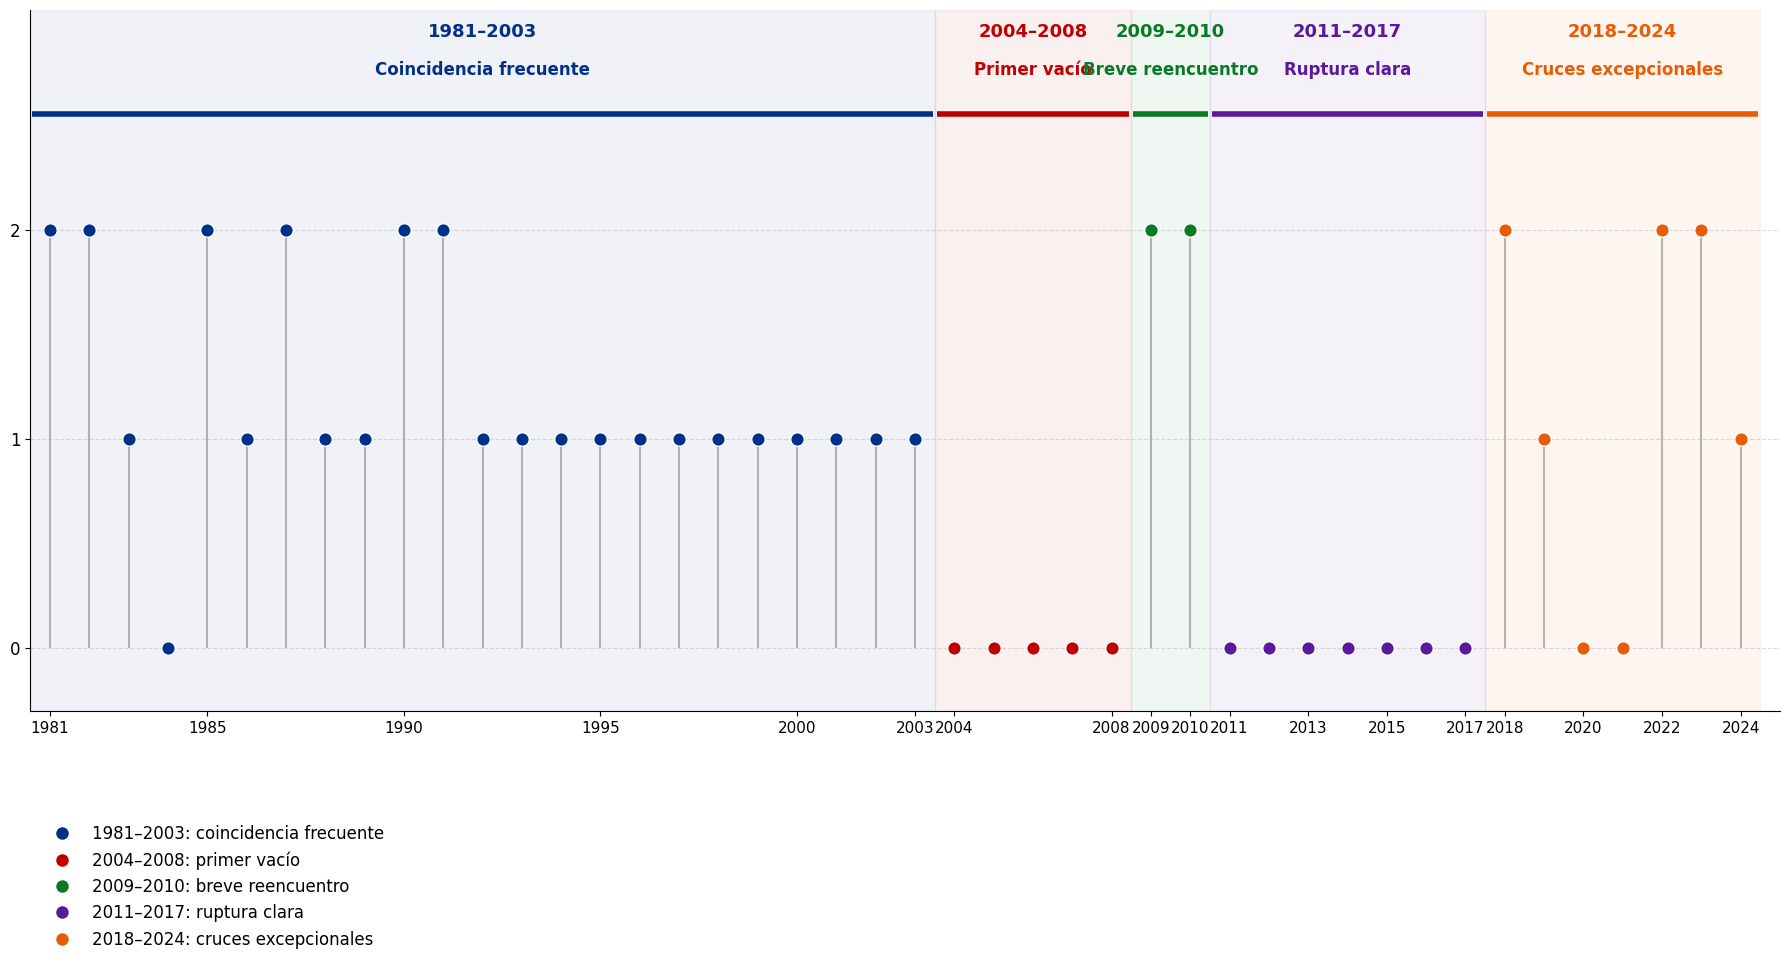

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
# =========================
# 1. Datos
# =========================
# Cada valor representa cuántas películas de las 6 más taquilleras
# de ese año fueron nominadas o ganadoras del Oscar a Mejor Película.

datos = {
    "año": [
        1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
        1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003,
        2004, 2005, 2006, 2007, 2008,
        2009, 2010,
        2011, 2012, 2013, 2014, 2015, 2016, 2017,
        2018, 2019, 2020, 2021, 2022, 2023, 2024
    ],
    "reconocidas": [
        2, 2, 1, 0, 2, 1, 2, 1, 1, 2,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1,
        0, 0, 0, 0, 0,
        2, 2,
        0, 0, 0, 0, 0, 0, 0,
        2, 1, 0, 0, 2, 2, 1
    ]
}
df = pd.DataFrame(datos)

# =========================
# 2. Clasificación por periodos
# =========================

def clasificar_periodo(año):
    if 1981 <= año <= 2003:
        return "1981–2003"
    elif 2004 <= año <= 2008:
        return "2004–2008"
    elif 2009 <= año <= 2010:
        return "2009–2010"
    elif 2011 <= año <= 2017:
        return "2011–2017"
    elif 2018 <= año <= 2024:
        return "2018–2024"

df["periodo"] = df["año"].apply(clasificar_periodo)

colores = {
    "1981–2003": "#003087",
    "2004–2008": "#C00000",
    "2009–2010": "#087A24",
    "2011–2017": "#5A189A",
    "2018–2024": "#E85D04"
}

# =========================
# 3. Crear figura
# =========================

plt.figure(figsize=(18, 10))
ax = plt.gca()

# Fondo por periodos
periodos = [
    (1981, 2003, "#003087", "1981–2003", "Coincidencia frecuente"),
    (2004, 2008, "#C00000", "2004–2008", "Primer vacío"),
    (2009, 2010, "#087A24", "2009–2010", "Breve reencuentro"),
    (2011, 2017, "#5A189A", "2011–2017", "Ruptura clara"),
    (2018, 2024, "#E85D04", "2018–2024", "Cruces excepcionales")
]


# Líneas verticales y puntos
for _, fila in df.iterrows():
    color = colores[fila["periodo"]]
    ax.vlines(
        x=fila["año"],
        ymin=0,
        ymax=fila["reconocidas"],
        color="#B8B8B8",
        linewidth=1.5,
        zorder=1
    )
    ax.scatter(
        fila["año"],
        fila["reconocidas"],
        s=95,
        color=color,
        edgecolor="white",
        linewidth=1,
        zorder=3
    )

# =========================
# 4. Ejes y estilo
# =========================
for inicio, fin, color, titulo, subtitulo in periodos:
    ax.axvspan(inicio - 0.5, fin + 0.5, color=color, alpha=0.06)
    ax.hlines(
        y=2.55,
        xmin=inicio - 0.45,
        xmax=fin + 0.45,
        color=color,
        linewidth=4
    )
    ax.text(
        (inicio + fin) / 2,
        2.90,
        titulo,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=color
    )
    ax.text(
        (inicio + fin) / 2,
        2.72,
        subtitulo,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=color
    )


ax.set_xlim(1980.5, 2025)
ax.set_ylim(-0.3, 3.05)

ax.set_xticks([1981, 1985, 1990, 1995, 2000, 2003, 2004, 2008, 2009, 2010, 2011, 2013, 2015, 2017, 2018, 2020, 2022, 2024])
ax.set_yticks([0, 1, 2])

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=12)

# =========================
# 5. Leyenda
# =========================

leyenda = [
    Line2D([0], [0], marker="o", color="w", label="1981–2003: coincidencia frecuente",
           markerfacecolor="#003087", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2004–2008: primer vacío",
           markerfacecolor="#C00000", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2009–2010: breve reencuentro",
           markerfacecolor="#087A24", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2011–2017: ruptura clara",
           markerfacecolor="#5A189A", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2018–2024: cruces excepcionales",
           markerfacecolor="#E85D04", markersize=10),
]

ax.legend(
    handles=leyenda,
    loc="lower left",
    bbox_to_anchor=(0, -0.36),
    frameon=False,
    fontsize=12
)

# =========================
# 7. Guardar imagen
# =========================

plt.tight_layout()

plt.savefig(
    "visualizacion_grieta_taquilla_oscar.png",
    dpi=400,
     bbox_inches="tight"
)

plt.show()

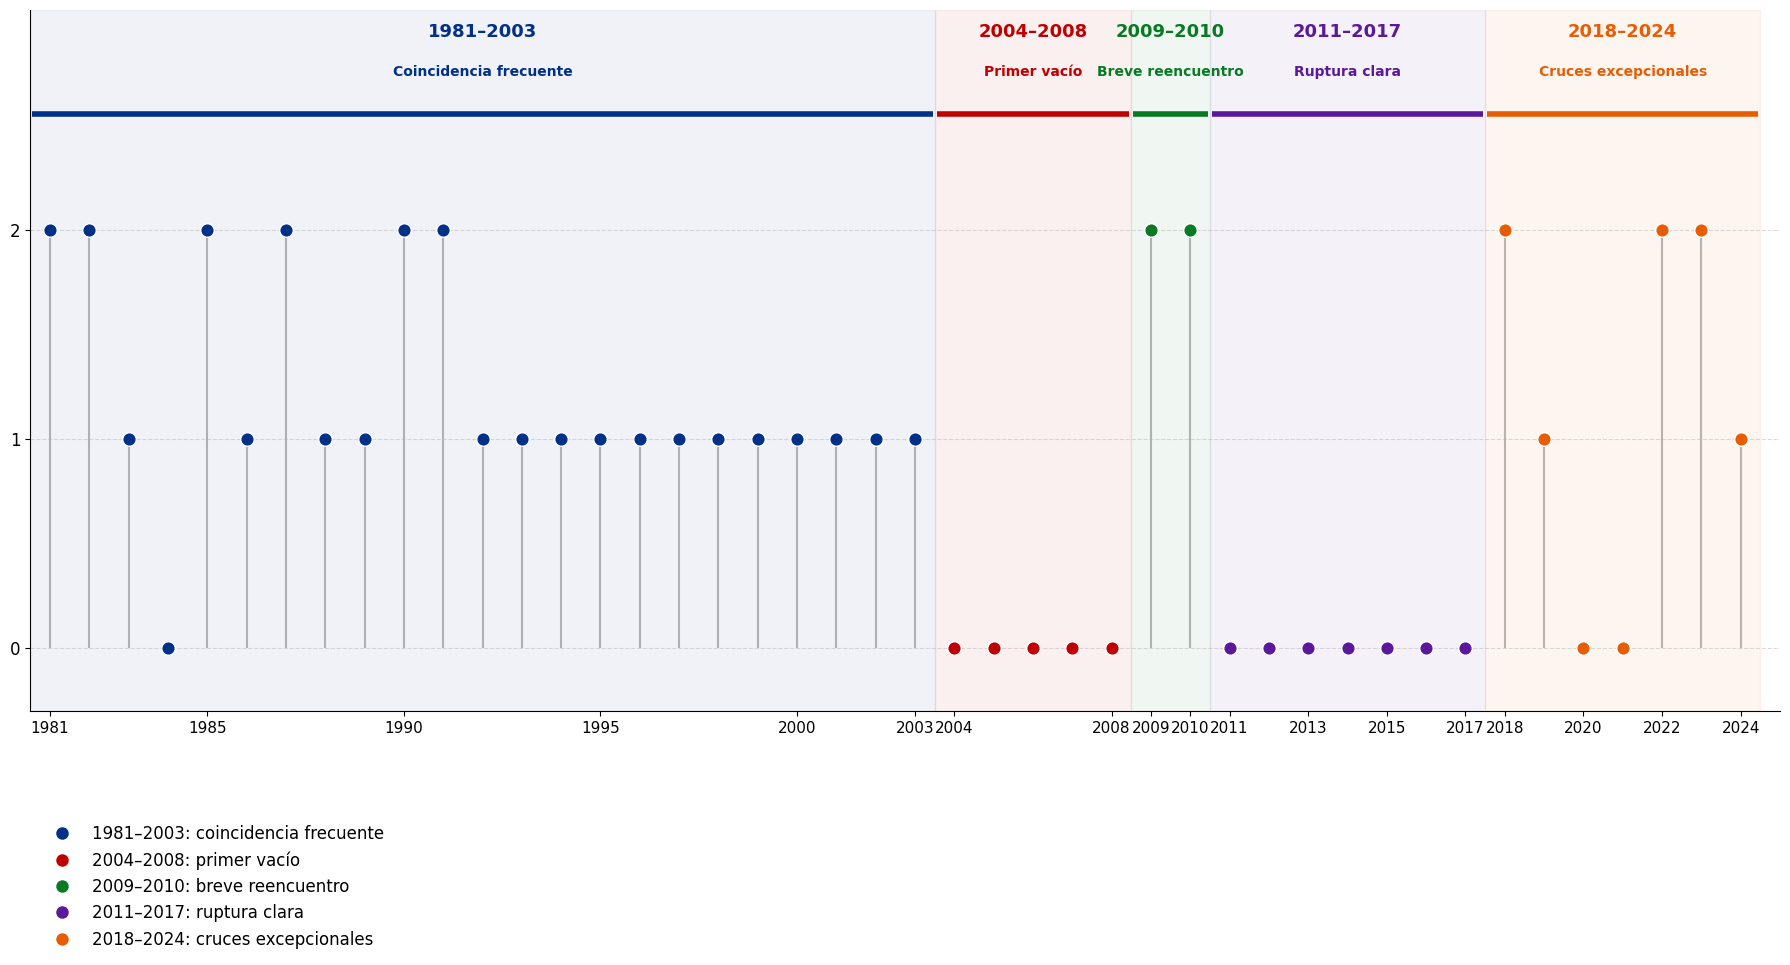

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
# =========================
# 1. Datos
# =========================
# Cada valor representa cuántas películas de las 6 más taquilleras
# de ese año fueron nominadas o ganadoras del Oscar a Mejor Película.

datos = {
    "año": [
        1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
        1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003,
        2004, 2005, 2006, 2007, 2008,
        2009, 2010,
        2011, 2012, 2013, 2014, 2015, 2016, 2017,
        2018, 2019, 2020, 2021, 2022, 2023, 2024
    ],
    "reconocidas": [
        2, 2, 1, 0, 2, 1, 2, 1, 1, 2,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1,
        0, 0, 0, 0, 0,
        2, 2,
        0, 0, 0, 0, 0, 0, 0,
        2, 1, 0, 0, 2, 2, 1
    ]
}
df = pd.DataFrame(datos)

# =========================
# 2. Clasificación por periodos
# =========================

def clasificar_periodo(año):
    if 1981 <= año <= 2003:
        return "1981–2003"
    elif 2004 <= año <= 2008:
        return "2004–2008"
    elif 2009 <= año <= 2010:
        return "2009–2010"
    elif 2011 <= año <= 2017:
        return "2011–2017"
    elif 2018 <= año <= 2024:
        return "2018–2024"

df["periodo"] = df["año"].apply(clasificar_periodo)

colores = {
    "1981–2003": "#003087",
    "2004–2008": "#C00000",
    "2009–2010": "#087A24",
    "2011–2017": "#5A189A",
    "2018–2024": "#E85D04"
}

# =========================
# 3. Crear figura
# =========================

plt.figure(figsize=(18, 10))
ax = plt.gca()

# Fondo por periodos
periodos = [
    (1981, 2003, "#003087", "1981–2003", "Coincidencia frecuente"),
    (2004, 2008, "#C00000", "2004–2008", "Primer vacío"),
    (2009, 2010, "#087A24", "2009–2010", "Breve reencuentro"),
    (2011, 2017, "#5A189A", "2011–2017", "Ruptura clara"),
    (2018, 2024, "#E85D04", "2018–2024", "Cruces excepcionales")
]


# Líneas verticales y puntos
for _, fila in df.iterrows():
    color = colores[fila["periodo"]]
    ax.vlines(
        x=fila["año"],
        ymin=0,
        ymax=fila["reconocidas"],
        color="#B8B8B8",
        linewidth=1.5,
        zorder=1
    )
    ax.scatter(
        fila["año"],
        fila["reconocidas"],
        s=95,
        color=color,
        edgecolor="white",
        linewidth=1,
        zorder=3
    )

# =========================
# 4. Ejes y estilo
# =========================
for inicio, fin, color, titulo, subtitulo in periodos:
    ax.axvspan(inicio - 0.5, fin + 0.5, color=color, alpha=0.06)
    ax.hlines(
        y=2.55,
        xmin=inicio - 0.45,
        xmax=fin + 0.45,
        color=color,
        linewidth=4
    )
    ax.text(
        (inicio + fin) / 2,
        2.90,
        titulo,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=color
    )
    ax.text(
        (inicio + fin) / 2,
        2.72,
        subtitulo,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=color
    )




ax.set_xlim(1980.5, 2025)
ax.set_ylim(-0.3, 3.05)

ax.set_xticks([1981, 1985, 1990, 1995, 2000, 2003, 2004, 2008, 2009, 2010, 2011, 2013, 2015, 2017, 2018, 2020, 2022, 2024])
ax.set_yticks([0, 1, 2])

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=12)

# =========================
# 5. Leyenda
# =========================

leyenda = [
    Line2D([0], [0], marker="o", color="w", label="1981–2003: coincidencia frecuente",
           markerfacecolor="#003087", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2004–2008: primer vacío",
           markerfacecolor="#C00000", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2009–2010: breve reencuentro",
           markerfacecolor="#087A24", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2011–2017: ruptura clara",
           markerfacecolor="#5A189A", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="2018–2024: cruces excepcionales",
           markerfacecolor="#E85D04", markersize=10),
]

ax.legend(
    handles=leyenda,
    loc="lower left",
    bbox_to_anchor=(0, -0.36),
    frameon=False,
    fontsize=12
)

# =========================
# 7. Guardar imagen
# =========================

plt.tight_layout()

plt.savefig(
    "visualizacion_grieta_taquilla_oscar.png",
    dpi=400,
     bbox_inches="tight"
)
plt.show()

In [ ]:
from google.colab import files

files.download("visualizacion_grieta_taquilla_oscar.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>